# Language Detection — Text Cleaning & Preprocessing

Clean the raw text (lowercase, strip URLs / punctuation / digits, remove stopwords, apply Porter stemming) and save a tidy `clean_text` + `label` dataset for modeling.

## 1. Imports & Load Raw Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')
from utils import load_data, clean_text
sns.set_style('whitegrid')
%matplotlib inline

In [2]:
df = load_data()
print('Raw shape:', df.shape)
df.head()

Raw shape: (10337, 2)


,Text,Language
0,"Nature, in the broadest sense, is the natural...",English
1,"""Nature"" can refer to the phenomena of the phy...",English
2,"The study of nature is a large, if not the onl...",English
3,"Although humans are part of nature, human acti...",English
4,[1] The word nature is borrowed from the Old F...,English


## 2. Handle Missing / Duplicate Rows

In [3]:
print('Missing:', df.isnull().sum().sum())
print('Duplicates:', df.duplicated().sum())
df = df.dropna(subset=['Text', 'Language']).drop_duplicates().reset_index(drop=True)
print('After cleanup:', df.shape)

Missing: 0
Duplicates: 66
After cleanup: (10271, 2)


## 3. Apply Text Cleaning

In [4]:
# clean_text: lowercase, strip urls/html/punctuation/digits, remove stopwords, Porter-stem
print('Example BEFORE:'); print(repr(df['Text'].iloc[0][:300]))
df['clean_text'] = df['Text'].astype(str).apply(clean_text)
print('\nExample AFTER:'); print(repr(df['clean_text'].iloc[0][:300]))

Example BEFORE:
' Nature, in the broadest sense, is the natural, physical, material world or universe.'

Example AFTER:
'nature in the broadest sense is the natural physical material world or universe'


## 4. Drop Rows That Became Empty After Cleaning

In [5]:
before = len(df)
df = df[df['clean_text'].str.strip().str.len() > 0].reset_index(drop=True)
print(f'Dropped {before - len(df)} rows that were empty after cleaning')
print('Remaining:', len(df))

Dropped 4 rows that were empty after cleaning
Remaining: 10267


## 5. Cleaned Text Length Comparison

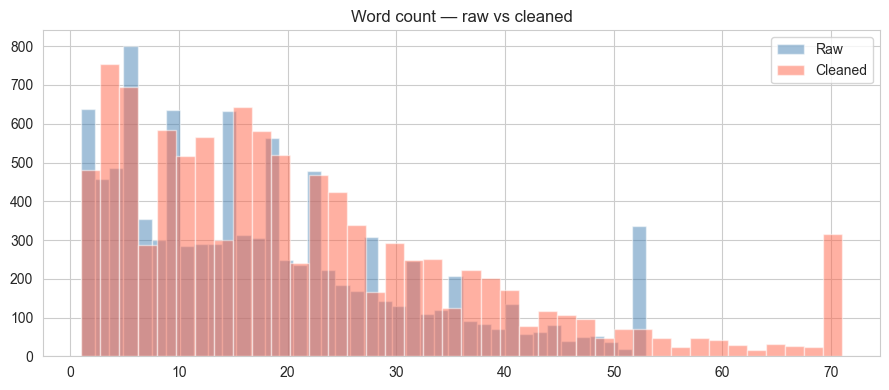

Mean words raw : 19.7
Mean words clean: 24.3


In [6]:
df['raw_words'] = df['Text'].astype(str).str.split().str.len()
df['clean_words'] = df['clean_text'].str.split().str.len()
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df['raw_words'].clip(upper=df['raw_words'].quantile(0.97)), bins=40, alpha=0.5, label='Raw', color='steelblue')
ax.hist(df['clean_words'].clip(upper=df['clean_words'].quantile(0.97)), bins=40, alpha=0.5, label='Cleaned', color='tomato')
ax.set_title('Word count — raw vs cleaned'); ax.legend()
plt.tight_layout(); plt.show()
print('Mean words raw :', round(df['raw_words'].mean(), 1))
print('Mean words clean:', round(df['clean_words'].mean(), 1))

## 6. Encode Label

In [7]:
# Map label to integer codes
df['label'] = df['Language'].astype('category')
label_mapping = dict(enumerate(df['label'].cat.categories))
df['label'] = df['label'].cat.codes
print('Label mapping:', label_mapping)

Label mapping: {0: 'Arabic', 1: 'Danish', 2: 'Dutch', 3: 'English', 4: 'French', 5: 'German', 6: 'Greek', 7: 'Hindi', 8: 'Italian', 9: 'Kannada', 10: 'Malayalam', 11: 'Portugeese', 12: 'Russian', 13: 'Spanish', 14: 'Sweedish', 15: 'Tamil', 16: 'Turkish'}


## 7. Save Cleaned Dataset

In [8]:
out = df[['clean_text', 'label']].copy()
out.to_csv('data/language_cleaned.csv', index=False)
print('Saved -> data/language_cleaned.csv', out.shape)
out.head()

Saved -> data/language_cleaned.csv (10267, 2)


,clean_text,label
0,nature in the broadest sense is the natural ph...,3
1,nature can refer to the phenomena of the physi...,3
2,the study of nature is a large if not the only...,3
3,although humans are part of nature human activ...,3
4,the word nature is borrowed from the old frenc...,3
